# 🎓 Proyecto Final: Clasificación de Imágenes Fashion-MNIST con Machine Learning Clásico

**Materia**: Aprendizaje de Máquina y Análisis de Datos  
**Dataset**: Fashion-MNIST (Zalando Research)  
**Enfoque**: Machine Learning clásico con extracción manual de características visuales  

---

> ⚠️ **IMPORTANTE**: Este proyecto **NO** utiliza Deep Learning, CNN, TensorFlow ni PyTorch. Se emplea exclusivamente Machine Learning clásico con ingeniería de características visuales extraídas manualmente.

## 📑 Tabla de Contenidos

1. [Introducción](#1-introducción)
2. [Comprensión del Problema](#2-comprensión-del-problema)
3. [Configuración del Entorno](#3-configuración-del-entorno)
4. [Carga del Dataset](#4-carga-del-dataset)
5. [Selección y Justificación de Clases](#5-selección-y-justificación-de-clases)
6. [Análisis Exploratorio de Datos (EDA)](#6-análisis-exploratorio-de-datos-eda)
7. [Preprocesamiento de Imágenes](#7-preprocesamiento-de-imágenes)
8. [Extracción de Características Visuales](#8-extracción-de-características-visuales)
9. [Dataset Tabular Final](#9-dataset-tabular-final)
10. [División Train/Test](#10-división-traintest)
11. [Modelos Obligatorios](#11-modelos-obligatorios)
12. [Validación Cruzada e Hiperparámetros](#12-validación-cruzada-e-hiperparámetros)
13. [PCA - Análisis de Componentes Principales](#13-pca---análisis-de-componentes-principales)
14. [Pipelines](#14-pipelines)
15. [Evaluación Final del Mejor Modelo](#15-evaluación-final-del-mejor-modelo)
16. [Opción de Rechazo](#16-opción-de-rechazo)
17. [Conclusiones](#17-conclusiones)

---
## 1. Introducción

### Contexto

La clasificación de imágenes es uno de los problemas fundamentales en la visión por computadora. Tradicionalmente, antes del auge del deep learning, los sistemas de clasificación se basaban en la **extracción manual de características visuales** seguida del entrenamiento de modelos clásicos de Machine Learning.

En este proyecto implementamos un pipeline completo de clasificación de imágenes usando el dataset **Fashion-MNIST** de Zalando Research, siguiendo el enfoque clásico:

1. **Imagen** → Extracción de características (intensidad, forma, textura) → **Vector numérico**
2. **Vector numérico** → Modelo de ML clásico → **Predicción de clase**

### ¿Por qué Machine Learning clásico y no Deep Learning?

El objetivo pedagógico de este proyecto es demostrar:
- Cómo se construye un sistema de clasificación de imágenes **sin redes neuronales profundas**
- La importancia de la **ingeniería de características** (feature engineering)
- Cómo técnicas clásicas de procesamiento de imágenes (Otsu, Canny, LBP, GLCM, HOG) pueden capturar información discriminativa
- La comparación sistemática de múltiples modelos de ML
- La aplicación de técnicas de evaluación como PCA, validación cruzada y opción de rechazo

---
## 2. Comprensión del Problema

### ¿Cuál es el problema de clasificación?
Se trata de un problema de **clasificación multiclase supervisada**: dada una imagen de 28×28 píxeles en escala de grises de una prenda de vestir o accesorio, el sistema debe predecir a cuál de las clases seleccionadas pertenece.

### ¿Es binario o multiclase?
Es un problema **multiclase**. Aunque Fashion-MNIST tiene 10 clases originales, en este proyecto trabajamos con **5 clases seleccionadas** (0, 1, 3, 6, 8), lo que mantiene la naturaleza multiclase del problema.

### Clases originales de Fashion-MNIST (10 clases)

| ID | Nombre | Descripción |
|----|--------|-------------|
| 0 | T-shirt/top | Camiseta |
| 1 | Trouser | Pantalón |
| 2 | Pullover | Suéter |
| 3 | Dress | Vestido |
| 4 | Coat | Abrigo |
| 5 | Sandal | Sandalia |
| 6 | Shirt | Camisa |
| 7 | Sneaker | Tenis |
| 8 | Bag | Bolso |
| 9 | Ankle boot | Bota |

### ¿Por qué no se usaron todas las clases?
- El proyecto se enfoca en demostrar el pipeline completo de ML clásico con extracción de características
- Un subconjunto de 5 clases permite un análisis más profundo y manejable
- Se reduce el tiempo de entrenamiento sin sacrificar la complejidad del problema
- El subconjunto incluye tanto clases fáciles como difíciles de separar

### ¿Las clases son visualmente separables?
- **Clases fácilmente separables**: Trouser y Bag tienen siluetas muy diferentes entre sí y respecto al resto
- **Clases difícilmente separables**: T-shirt/top y Shirt son visualmente muy similares (ambas son prendas superiores con forma de "T")
- **Caso intermedio**: Dress tiene una silueta que puede confundirse parcialmente con T-shirt/top

### Dificultades esperadas
1. La similitud visual entre T-shirt/top y Shirt puede generar confusión significativa
2. Las imágenes son de baja resolución (28×28), limitando la información disponible
3. La variabilidad intra-clase (diferentes estilos de camisetas, por ejemplo) dificulta la generalización
4. Las características extraídas manualmente pueden no capturar toda la información que una CNN aprendería

---
## 3. Configuración del Entorno

In [1]:
# ============================================================================
# Configuración inicial y detección de entorno
# ============================================================================
import sys
import os
from pathlib import Path

# Detectar si estamos en Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🌐 Ejecutando en Google Colab")
    # En Colab, montar Google Drive y configurar rutas
    from google.colab import drive
    drive.mount('/content/drive')
    # Ajustar esta ruta según donde esté el proyecto en Drive
    PROJECT_ROOT = Path('/content/drive/MyDrive/fashion-mnist')
else:
    print("💻 Ejecutando en entorno local")
    # El notebook está en notebooks/, la raíz es un nivel arriba
    PROJECT_ROOT = Path(os.path.abspath('')).parent
    if not (PROJECT_ROOT / 'data' / 'fashion').exists():
        PROJECT_ROOT = Path(os.path.abspath(''))

# Agregar src al path
sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

print(f"📁 Raíz del proyecto: {PROJECT_ROOT}")
print(f"📁 Dataset en: {PROJECT_ROOT / 'data' / 'fashion'}")

💻 Ejecutando en entorno local
📁 Raíz del proyecto: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist
📁 Dataset en: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\data\fashion


In [2]:
# ============================================================================
# Importaciones generales
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import joblib

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Configuración de matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Semilla fija para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Librerías importadas correctamente")
print(f"  NumPy: {np.__version__}")
print(f"  Pandas: {pd.__version__}")
print(f"  Scikit-learn: {__import__('sklearn').__version__}")

✓ Librerías importadas correctamente
  NumPy: 2.4.6
  Pandas: 3.0.3
  Scikit-learn: 1.8.0


In [3]:
# ============================================================================
# Importar módulos del proyecto
# ============================================================================
from src.data_loader import (
    load_fashion_mnist, filter_classes, get_class_names,
    create_stratified_sample, SELECTED_CLASSES, CLASS_NAMES, IMG_SIZE
)
from src.utils import ensure_directories, set_random_seed, format_time, print_section_header
from src.eda import (
    plot_class_distribution, plot_sample_images, plot_intensity_histograms,
    plot_brightness_analysis, plot_contrast_analysis, plot_texture_analysis,
    plot_edge_analysis, detect_similar_classes, detect_outliers, dataset_summary
)
from src.preprocessing import (
    normalize_images, reshape_images, segment_images, compare_original_vs_segmented
)
from src.features import (
    extract_features_batch, get_feature_documentation,
    extract_intensity_features, extract_shape_features, extract_texture_features
)
from src.models import (
    get_base_models, create_pipeline, train_and_evaluate, train_all_models,
    get_hyperparameter_grids, hyperparameter_search, cross_validate_models
)
from src.evaluation import (
    plot_confusion_matrix, plot_confusion_matrices_grid, get_full_metrics,
    create_comparison_table, plot_model_comparison, plot_correct_predictions,
    plot_incorrect_predictions, identify_confused_classes, save_comparison_csv
)
from src.reject_option import (
    get_prediction_probabilities, ensure_probability_model,
    evaluate_with_rejection, plot_reject_option_analysis,
    plot_rejected_samples, analyze_rejected_by_class, full_reject_analysis
)

# Crear directorios de salida
dirs = ensure_directories()

# Establecer semilla
set_random_seed(RANDOM_STATE)

print("\n✓ Todos los módulos del proyecto importados correctamente")

✓ Directorios del proyecto creados/verificados:
  → figures: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures
  → tables: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\tables
  → models: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\models
  → processed: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\data\processed
  → notebooks: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\notebooks
✓ Semilla aleatoria establecida: 42

✓ Todos los módulos del proyecto importados correctamente


---
## 4. Carga del Dataset

In [4]:
print_section_header("4. CARGA DEL DATASET FASHION-MNIST")

# Cargar dataset completo
X_train_full, y_train_full, X_test_full, y_test_full = load_fashion_mnist(
    data_path=str(PROJECT_ROOT / 'data' / 'fashion')
)

print(f"\n📊 Resumen del dataset completo:")
print(f"  Train: {X_train_full.shape[0]:,} imágenes, shape {X_train_full.shape}")
print(f"  Test:  {X_test_full.shape[0]:,} imágenes, shape {X_test_full.shape}")
print(f"  Total: {X_train_full.shape[0] + X_test_full.shape[0]:,} imágenes")
print(f"  Tamaño de imagen: {IMG_SIZE}×{IMG_SIZE} = {IMG_SIZE**2} píxeles")
print(f"  Canales: 1 (escala de grises)")
print(f"  Tipo de dato: {X_train_full.dtype}")
print(f"  Rango de valores: [{X_train_full.min()}, {X_train_full.max()}]")
print(f"  Clases totales: {len(np.unique(y_train_full))}")
print(f"  Clases: {np.unique(y_train_full)}")


  4. CARGA DEL DATASET FASHION-MNIST

Cargando dataset Fashion-MNIST...
  ✓ Datos de entrenamiento: 60,000 imágenes
  ✓ Datos de prueba: 10,000 imágenes
  ✓ Dimensión de cada imagen: 28x28 = 784 píxeles
  ✓ Tipo de dato: uint8
  ✓ Rango de valores: [0, 255]
  ✓ Clases únicas: [0 1 2 3 4 5 6 7 8 9]

📊 Resumen del dataset completo:
  Train: 60,000 imágenes, shape (60000, 784)
  Test:  10,000 imágenes, shape (10000, 784)
  Total: 70,000 imágenes
  Tamaño de imagen: 28×28 = 784 píxeles
  Canales: 1 (escala de grises)
  Tipo de dato: uint8
  Rango de valores: [0, 255]
  Clases totales: 10
  Clases: [0 1 2 3 4 5 6 7 8 9]


---
## 5. Selección y Justificación de Clases

### Clases seleccionadas

De las 10 clases originales de Fashion-MNIST, seleccionamos **5 clases representativas**:

| ID | Clase | Razón de inclusión |
|----|-------|-------------------|
| 0 | T-shirt/top | Prenda básica de torso. Se confunde con Shirt |
| 1 | Trouser | Silueta vertical única. Fácil de distinguir |
| 3 | Dress | Silueta alargada. Categoría intermedia |
| 6 | Shirt | Similar a T-shirt/top. Caso de estudio para confusión |
| 8 | Bag | No es prenda. Silueta completamente diferente |

### Justificación

Esta selección permite:
- **Clases fáciles de separar**: Trouser y Bag tienen formas muy distintas
- **Clases difíciles de separar**: T-shirt/top y Shirt son visualmente similares
- **Variedad de siluetas**: Desde formas compactas (Bag) hasta alargadas (Trouser, Dress)
- **Problema multiclase no trivial**: 5 clases con diferentes niveles de dificultad

In [5]:
print_section_header("5. FILTRADO DE CLASES SELECCIONADAS")

# Filtrar a las clases seleccionadas
X_train, y_train = filter_classes(X_train_full, y_train_full, SELECTED_CLASSES)
X_test, y_test = filter_classes(X_test_full, y_test_full, SELECTED_CLASSES)

# Obtener nombres de clases
class_names = get_class_names(selected_only=True)

print(f"\n📊 Dataset filtrado:")
print(f"  Train: {X_train.shape[0]:,} imágenes")
print(f"  Test:  {X_test.shape[0]:,} imágenes")
print(f"  Clases: {SELECTED_CLASSES}")
print(f"  Nombres: {class_names}")


  5. FILTRADO DE CLASES SELECCIONADAS


✓ Dataset filtrado a 5 clases:
  → Clase 0 (T-shirt/top): 6,000 imágenes
  → Clase 1 (Trouser): 6,000 imágenes
  → Clase 3 (Dress): 6,000 imágenes
  → Clase 6 (Shirt): 6,000 imágenes
  → Clase 8 (Bag): 6,000 imágenes
  → Total: 30,000 imágenes (de 60,000 originales)

✓ Dataset filtrado a 5 clases:
  → Clase 0 (T-shirt/top): 1,000 imágenes
  → Clase 1 (Trouser): 1,000 imágenes
  → Clase 3 (Dress): 1,000 imágenes
  → Clase 6 (Shirt): 1,000 imágenes
  → Clase 8 (Bag): 1,000 imágenes
  → Total: 5,000 imágenes (de 10,000 originales)

📊 Dataset filtrado:
  Train: 30,000 imágenes
  Test:  5,000 imágenes
  Clases: [0, 1, 3, 6, 8]
  Nombres: {0: 'T-shirt/top', 1: 'Trouser', 3: 'Dress', 6: 'Shirt', 8: 'Bag'}


In [6]:
# ============================================================================
# OPCIÓN: Crear muestra estratificada para pruebas rápidas
# Descomentar las siguientes líneas para usar una muestra más pequeña
# ============================================================================

USE_SAMPLE = True  # Cambiar a False para usar todos los datos
SAMPLE_SIZE = 10000  # Número de muestras de entrenamiento

if USE_SAMPLE:
    X_train, y_train = create_stratified_sample(X_train, y_train, n_samples=SAMPLE_SIZE)
    # Mantener test completo para evaluación más representativa
    print(f"\n⚡ Usando muestra estratificada de {len(X_train):,} imágenes de entrenamiento")
else:
    print(f"\n📊 Usando dataset completo: {len(X_train):,} imágenes de entrenamiento")


✓ Muestra estratificada creada: 9,999 imágenes
  → Clase 0 (T-shirt/top): 2,000 (20.0%)
  → Clase 1 (Trouser): 2,000 (20.0%)
  → Clase 3 (Dress): 2,000 (20.0%)
  → Clase 6 (Shirt): 1,999 (20.0%)
  → Clase 8 (Bag): 2,000 (20.0%)

⚡ Usando muestra estratificada de 9,999 imágenes de entrenamiento


---
## 6. Análisis Exploratorio de Datos (EDA)

En esta sección analizamos en profundidad las características del dataset para entender la naturaleza de los datos y anticipar posibles dificultades en la clasificación.

### 6.1 Resumen del Dataset

In [7]:
print_section_header("6. ANÁLISIS EXPLORATORIO DE DATOS (EDA)")

# Resumen estadístico
summary_df = dataset_summary(X_train, y_train, class_names)
print("\n📊 Resumen del dataset de entrenamiento:")
display(summary_df)


  6. ANÁLISIS EXPLORATORIO DE DATOS (EDA)


📊 Resumen del dataset de entrenamiento:


,Clase,Nombre,N_imágenes,Porcentaje,Brillo_medio,Brillo_std,Contraste_medio,Píxeles_activos_medio
0,0,T-shirt/top,2000,20.0%,0.325,0.114,0.319,423
1,1,Trouser,2000,20.0%,0.223,0.055,0.334,262
2,3,Dress,2000,20.0%,0.260,0.084,0.336,313
3,6,Shirt,1999,20.0%,0.330,0.130,0.299,458
4,8,Bag,2000,20.0%,0.354,0.114,0.341,425
5,-,TOTAL,9999,100.0%,0.298,0.114,0.326,376


### 6.2 Distribución de Clases

In [8]:
# Distribución de clases
fig = plot_class_distribution(
    y_train, class_names, 
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'distribucion_clases.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\distribucion_clases.png


**Observación**: El dataset Fashion-MNIST es balanceado por diseño. Cada clase tiene aproximadamente la misma cantidad de imágenes (~6,000 en train, ~1,000 en test). Esto significa que no necesitamos técnicas de balanceo de clases.

### 6.3 Muestras Representativas

In [9]:
# Muestras por clase
fig = plot_sample_images(
    X_train, y_train, class_names, n_per_class=8,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'muestras_por_clase.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\muestras_por_clase.png


**Observación**: Se puede apreciar la variabilidad intra-clase. Las camisetas (T-shirt/top) y camisas (Shirt) tienen formas muy similares, lo que anticipa que serán las clases más difíciles de separar. Los pantalones y bolsos tienen siluetas claramente distintas.

### 6.4 Histogramas de Intensidad

In [10]:
# Histogramas de intensidad por clase
fig = plot_intensity_histograms(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'histogramas_intensidad.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\histogramas_intensidad.png


**Observación**: Las distribuciones de intensidad son bimodales en la mayoría de clases: un pico grande en valores bajos (fondo oscuro, ~0) y un pico más pequeño en valores medios-altos (el objeto). Esto confirma que Fashion-MNIST tiene fondo negro y objeto en tonos de gris.

### 6.5 Análisis de Brillo y Contraste

In [11]:
# Análisis de brillo
fig = plot_brightness_analysis(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'analisis_brillo.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\analisis_brillo.png


In [12]:
# Análisis de contraste
fig = plot_contrast_analysis(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'analisis_contraste.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\analisis_contraste.png


**Observación**: 
- El **brillo promedio** varía entre clases: los pantalones tienden a ser más oscuros (menos área de objeto) mientras que los vestidos suelen ser más brillantes.
- El **contraste** (desviación estándar) es similar entre clases, pero los bolsos y pantalones muestran patrones ligeramente diferentes.

### 6.6 Análisis de Textura y Bordes

In [13]:
# Análisis de textura
fig = plot_texture_analysis(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'analisis_textura.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\analisis_textura.png


In [14]:
# Análisis de bordes
fig = plot_edge_analysis(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'analisis_bordes.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\analisis_bordes.png


### 6.7 Detección de Clases Similares

In [15]:
# Similitud entre clases
fig = detect_similar_classes(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'similitud_clases.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\similitud_clases.png

  Pares de clases más similares (excluyendo diagonal):
    ⚠ T-shirt/top ↔ Trouser: correlación = 0.726
    ⚠ T-shirt/top ↔ Dress: correlación = 0.859
    ⚠ T-shirt/top ↔ Shirt: correlación = 0.864
    ⚠ Trouser ↔ Dress: correlación = 0.878
    ⚠ Dress ↔ Shirt: correlación = 0.790


**Observación clave**: La matriz de similitud confirma nuestra hipótesis: **T-shirt/top y Shirt** tienen la correlación más alta entre sus imágenes promedio. Esto significa que estas dos clases serán las más difíciles de separar para nuestros modelos.

### 6.8 Detección de Outliers

In [16]:
# Outliers visuales
fig = detect_outliers(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'outliers.png')
)
plt.show()

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\outliers.png

  Outliers detectados:
    → Muy oscuros (brillo < 0.067): 22
    → Muy brillantes (brillo > 0.751): 0


---
## 7. Preprocesamiento de Imágenes

Antes de extraer características, aplicamos preprocesamiento básico a las imágenes:

1. **Reshape**: Convertir de vector 784 a matriz 28×28
2. **Normalización**: Escalar intensidades de [0, 255] a [0, 1]
3. **Segmentación**: Umbralización de Otsu para separar objeto del fondo

> **Nota**: Fashion-MNIST ya viene en escala de grises con fondo negro uniforme, por lo que no se requiere conversión RGB ni redimensionamiento. Sin embargo, la normalización y segmentación mejoran la calidad de las características extraídas.

In [17]:
print_section_header("7. PREPROCESAMIENTO DE IMÁGENES")

# Comparar imagen original vs segmentada
compare_original_vs_segmented(
    X_train, y_train, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'original_vs_segmentada.png')
)
plt.show()


  7. PREPROCESAMIENTO DE IMÁGENES

  ✓ Figura guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\figures\original_vs_segmentada.png


**Observación**: La segmentación por Otsu funciona bien para la mayoría de clases, separando claramente el objeto del fondo negro. Para la extracción de características, usaremos tanto la imagen completa (para características de intensidad y textura) como la máscara segmentada (para características de forma).

---
## 8. Extracción de Características Visuales

Este es el **corazón del proyecto**. Transformamos cada imagen 28×28 en un vector de características numéricas usando tres familias:

### Familias de características

| Familia | Técnica | Descripción |
|---------|---------|-------------|
| **Intensidad** | Estadísticas, histograma, zonas | Media, std, percentiles, brillo, contraste, entropía, histograma 16-bins, medias por zona 4×4 |
| **Forma y Bordes** | Otsu, Canny, Hu moments | Área, perímetro, bounding box, aspect ratio, centroide, momentos de Hu, densidad de bordes |
| **Textura** | LBP, GLCM, HOG | Local Binary Pattern, Gray-Level Co-occurrence Matrix, Histogram of Oriented Gradients |

In [18]:
print_section_header("8. EXTRACCIÓN DE CARACTERÍSTICAS VISUALES")

# Mostrar documentación de características
feature_docs = get_feature_documentation()
print(f"\n📊 Total de características a extraer: {len(feature_docs)}")
print(f"\n   Distribución por familia:")
print(feature_docs['Familia'].value_counts().to_string())

display(feature_docs.head(20))


  8. EXTRACCIÓN DE CARACTERÍSTICAS VISUALES


📊 Total de características a extraer: 103

   Distribución por familia:
Familia
Intensidad    45
Textura       22
Forma         18
Bordes        18


,Nombre,Familia,Descripción
0,intensity_mean,Intensidad,Media de intensidad de todos los píxeles
1,intensity_std,Intensidad,Desviación estándar de intensidad
2,intensity_min,Intensidad,Valor mínimo de intensidad
3,intensity_max,Intensidad,Valor máximo de intensidad
4,intensity_median,Intensidad,Mediana de intensidad
5,intensity_p25,Intensidad,Percentil 25 de intensidad
6,intensity_p75,Intensidad,Percentil 75 de intensidad
7,intensity_range,Intensidad,Rango de intensidad (max - min)
8,brightness,Intensidad,Brillo promedio de la imagen
9,contrast,Intensidad,Contraste (desviación estándar de intensidad)



🔍 Ejemplo de extracción para una imagen:

  Clase: T-shirt/top


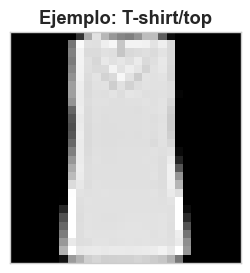


  Características de intensidad: 45
    intensity_mean: 0.4139
    intensity_std: 0.4310
    intensity_min: 0.0000
    intensity_max: 1.0000
    intensity_median: 0.0020

  Características de forma: 36
    object_area: 372.0000
    object_area_ratio: 0.4745
    perimeter: 77.0000
    bbox_x: 6.0000
    bbox_y: 0.0000

  Características de textura: 22
    lbp_hist_0: 0.0383
    lbp_hist_1: 0.0587
    lbp_hist_2: 0.0077
    lbp_hist_3: 0.0191
    lbp_hist_4: 0.0829


In [19]:
# Ejemplo: extraer características de una imagen
print("\n🔍 Ejemplo de extracción para una imagen:")
sample_img = X_train[0].astype(np.float64).reshape(28, 28) / 255.0

print(f"\n  Clase: {class_names[y_train[0]]}")

# Mostrar la imagen
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(sample_img, cmap='gray', vmin=0, vmax=1)
ax.set_title(f'Ejemplo: {class_names[y_train[0]]}', fontweight='bold')
ax.set_xticks([])
ax.set_yticks([])
plt.show()

# Extraer y mostrar algunas características
intensity_feats = extract_intensity_features(sample_img)
shape_feats = extract_shape_features(sample_img)
texture_feats = extract_texture_features(sample_img)

print(f"\n  Características de intensidad: {len(intensity_feats)}")
for k, v in list(intensity_feats.items())[:5]:
    print(f"    {k}: {v:.4f}")

print(f"\n  Características de forma: {len(shape_feats)}")
for k, v in list(shape_feats.items())[:5]:
    print(f"    {k}: {v:.4f}")

print(f"\n  Características de textura: {len(texture_feats)}")
for k, v in list(texture_feats.items())[:5]:
    print(f"    {k}: {v:.4f}")

In [20]:
# ============================================================================
# Extracción masiva de características
# ============================================================================
print("\n" + "="*60)
print("  EXTRAYENDO CARACTERÍSTICAS DE ENTRENAMIENTO")
print("="*60)

t_start = time.time()
features_train_df = extract_features_batch(X_train, n_jobs=1)
t_train = time.time() - t_start

print(f"\n  ✓ Extracción completada en {format_time(t_train)}")
print(f"  ✓ Shape: {features_train_df.shape}")


  EXTRAYENDO CARACTERÍSTICAS DE ENTRENAMIENTO

  Extrayendo características de 9,999 imágenes...
    Progreso: 500/9,999 (5.0%)
    Progreso: 1,000/9,999 (10.0%)
    Progreso: 1,500/9,999 (15.0%)
    Progreso: 2,000/9,999 (20.0%)
    Progreso: 2,500/9,999 (25.0%)
    Progreso: 3,000/9,999 (30.0%)
    Progreso: 3,500/9,999 (35.0%)
    Progreso: 4,000/9,999 (40.0%)
    Progreso: 4,500/9,999 (45.0%)
    Progreso: 5,000/9,999 (50.0%)
    Progreso: 5,500/9,999 (55.0%)
    Progreso: 6,000/9,999 (60.0%)
    Progreso: 6,500/9,999 (65.0%)
    Progreso: 7,000/9,999 (70.0%)
    Progreso: 7,500/9,999 (75.0%)
    Progreso: 8,000/9,999 (80.0%)
    Progreso: 8,500/9,999 (85.0%)
    Progreso: 9,000/9,999 (90.0%)
    Progreso: 9,500/9,999 (95.0%)
    Progreso: 9,999/9,999 (100.0%)
  ✓ Extracción completada: 103 características x 9,999 imágenes

  ✓ Extracción completada en 22.86 s
  ✓ Shape: (9999, 103)


In [21]:
print("\n" + "="*60)
print("  EXTRAYENDO CARACTERÍSTICAS DE PRUEBA")
print("="*60)

t_start = time.time()
features_test_df = extract_features_batch(X_test, n_jobs=1)
t_test = time.time() - t_start

print(f"\n  ✓ Extracción completada en {format_time(t_test)}")
print(f"  ✓ Shape: {features_test_df.shape}")


  EXTRAYENDO CARACTERÍSTICAS DE PRUEBA

  Extrayendo características de 5,000 imágenes...
    Progreso: 500/5,000 (10.0%)
    Progreso: 1,000/5,000 (20.0%)
    Progreso: 1,500/5,000 (30.0%)
    Progreso: 2,000/5,000 (40.0%)
    Progreso: 2,500/5,000 (50.0%)
    Progreso: 3,000/5,000 (60.0%)
    Progreso: 3,500/5,000 (70.0%)
    Progreso: 4,000/5,000 (80.0%)
    Progreso: 4,500/5,000 (90.0%)
    Progreso: 5,000/5,000 (100.0%)
  ✓ Extracción completada: 103 características x 5,000 imágenes

  ✓ Extracción completada en 12.27 s
  ✓ Shape: (5000, 103)


---
## 9. Dataset Tabular Final

Ahora construimos el dataset tabular final donde cada fila es una imagen y cada columna una característica extraída.

In [22]:
print_section_header("9. DATASET TABULAR FINAL")

# Añadir etiquetas y metadata
features_train_df['y'] = y_train
features_train_df['label_name'] = [class_names[y] for y in y_train]
features_train_df['split'] = 'train'

features_test_df['y'] = y_test
features_test_df['label_name'] = [class_names[y] for y in y_test]
features_test_df['split'] = 'test'

# Combinar train y test
features_full_df = pd.concat([features_train_df, features_test_df], ignore_index=True)

print(f"📊 Dataset tabular completo:")
print(f"  Filas (imágenes): {len(features_full_df):,}")
print(f"  Columnas (características + metadata): {features_full_df.shape[1]}")
print(f"  Características numéricas: {features_full_df.shape[1] - 3}")

# Mostrar primeras filas
display(features_full_df.head())


  9. DATASET TABULAR FINAL

📊 Dataset tabular completo:
  Filas (imágenes): 14,999
  Columnas (características + metadata): 106
  Características numéricas: 103


,intensity_mean,intensity_std,intensity_min,intensity_max,intensity_median,intensity_p25,intensity_p75,intensity_range,brightness,contrast,...,glcm_ASM,hog_mean,hog_std,hog_max,hog_min,hog_median,texture_entropy,y,label_name,split
0,0.413946,0.431004,0.0,1.000000,0.001961,0.0,0.878431,1.000000,0.413946,0.431004,...,0.318573,0.080095,0.146159,0.482725,0.0,0.004045,3.524332,0,T-shirt/top,train
1,0.453106,0.346503,0.0,1.000000,0.639216,0.0,0.718627,1.000000,0.453106,0.346503,...,0.158460,0.110986,0.124337,0.503437,0.0,0.055554,5.377928,6,Shirt,train
2,0.138240,0.226833,0.0,0.996078,0.000000,0.0,0.211765,0.996078,0.138240,0.226833,...,0.345953,0.127872,0.106895,0.347054,0.0,0.109863,3.988744,3,Dress,train
3,0.234389,0.264954,0.0,1.000000,0.007843,0.0,0.486275,1.000000,0.234389,0.264954,...,0.246054,0.125441,0.109738,0.350531,0.0,0.092732,4.463191,8,Bag,train
4,0.225310,0.215884,0.0,1.000000,0.211765,0.0,0.372549,1.000000,0.225310,0.215884,...,0.150674,0.125935,0.109171,0.337936,0.0,0.097011,5.250574,6,Shirt,train


In [23]:
# Guardar CSV de características
csv_path = PROJECT_ROOT / 'data' / 'processed' / 'fashion_mnist_features.csv'
csv_path.parent.mkdir(parents=True, exist_ok=True)
features_full_df.to_csv(csv_path, index=False)
print(f"\n✓ Dataset tabular guardado: {csv_path}")
print(f"  Tamaño: {csv_path.stat().st_size / (1024*1024):.1f} MB")


✓ Dataset tabular guardado: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\data\processed\fashion_mnist_features.csv
  Tamaño: 24.9 MB


In [24]:
# Documentación de variables
feature_docs = get_feature_documentation()
docs_path = PROJECT_ROOT / 'outputs' / 'tables' / 'feature_documentation.csv'
feature_docs.to_csv(docs_path, index=False)
print(f"✓ Documentación de características guardada: {docs_path}")
print(f"\n📊 Resumen de familias de características:")
display(feature_docs['Familia'].value_counts().to_frame('N_características'))

✓ Documentación de características guardada: C:\Users\jhonm\OneDrive\Desktop\SistemaOctavo\Aprendizaje\Proyecto\fashion-mnist\outputs\tables\feature_documentation.csv

📊 Resumen de familias de características:


,N_características
Familia,
Intensidad,45
Textura,22
Forma,18
Bordes,18


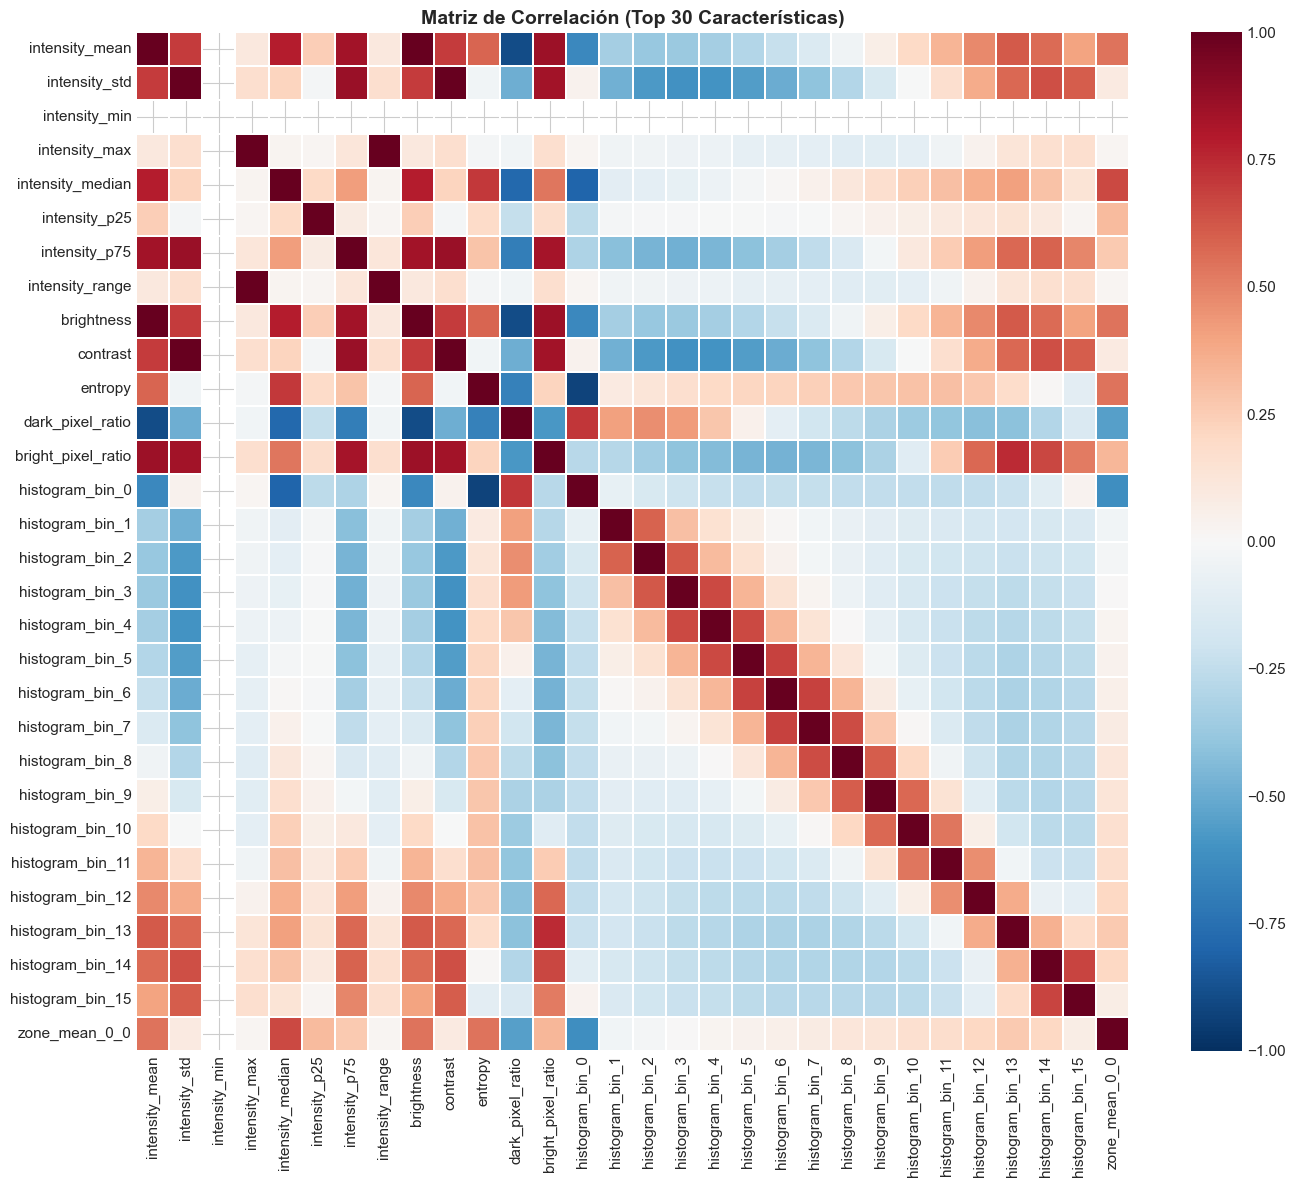


⚠ Características con correlación > 0.95:
  intensity_mean ↔ brightness: 1.000
  intensity_std ↔ contrast: 1.000
  intensity_max ↔ intensity_range: 1.000
  entropy ↔ lbp_hist_8: -0.960
  entropy ↔ texture_entropy: 1.000
  histogram_bin_0 ↔ lbp_hist_8: 0.972
  zone_mean_0_1 ↔ zone_mean_0_2: 0.957
  zone_mean_1_1 ↔ zone_mean_1_2: 0.954
  zone_mean_2_0 ↔ zone_mean_2_3: 0.951
  object_area ↔ object_area_ratio: 1.000


In [25]:
# Análisis de correlación
feature_cols = [c for c in features_train_df.columns if c not in ['y', 'label_name', 'split']]

# Manejar valores infinitos o NaN
features_train_clean = features_train_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
features_test_clean = features_test_df[feature_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

corr_matrix = features_train_clean.corr()

# Heatmap de correlación (top 30 características)
fig, ax = plt.subplots(figsize=(14, 12))
top_features = feature_cols[:30]
sns.heatmap(corr_matrix.loc[top_features, top_features], 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.1, fmt='.1f')
ax.set_title('Matriz de Correlación (Top 30 Características)', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'outputs' / 'figures' / 'correlacion_caracteristicas.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

# Detectar características muy correlacionadas
high_corr = []
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr.append((feature_cols[i], feature_cols[j], corr_matrix.iloc[i, j]))

if high_corr:
    print(f"\n⚠ Características con correlación > 0.95:")
    for f1, f2, corr in high_corr[:10]:
        print(f"  {f1} ↔ {f2}: {corr:.3f}")
else:
    print("\n✓ No hay características con correlación > 0.95")

---
## 10. División Train/Test

Aunque Fashion-MNIST ya viene con división train/test, construimos una división controlada sobre nuestro dataset tabular de características para asegurar reproducibilidad y estratificación.

In [26]:
print_section_header("10. DIVISIÓN TRAIN/TEST")

# Preparar datos para modelos
X_feat_train = features_train_clean.values
y_feat_train = y_train.copy()
X_feat_test = features_test_clean.values
y_feat_test = y_test.copy()

# También crear una división adicional controlada
X_all = np.vstack([X_feat_train, X_feat_test])
y_all = np.concatenate([y_feat_train, y_feat_test])

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)

print(f"📊 División del dataset tabular:")
print(f"\n  Usando división original Fashion-MNIST:")
print(f"    Train: {X_feat_train.shape}")
print(f"    Test:  {X_feat_test.shape}")

print(f"\n  División controlada (80/20 estratificada):")
print(f"    Train: {X_train_split.shape}")
print(f"    Test:  {X_test_split.shape}")

# Verificar proporciones
print(f"\n  Verificación de estratificación (división controlada):")
for cls_id in sorted(class_names.keys()):
    train_pct = 100 * np.mean(y_train_split == cls_id)
    test_pct = 100 * np.mean(y_test_split == cls_id)
    print(f"    Clase {cls_id} ({class_names[cls_id]}): Train={train_pct:.1f}%, Test={test_pct:.1f}%")

# Usaremos la división original para los modelos
print("\n  ℹ Para los modelos, usaremos la división original de Fashion-MNIST.")
print("    Esto permite comparar con benchmarks publicados.")


  10. DIVISIÓN TRAIN/TEST

📊 División del dataset tabular:

  Usando división original Fashion-MNIST:
    Train: (9999, 103)
    Test:  (5000, 103)

  División controlada (80/20 estratificada):
    Train: (11999, 103)
    Test:  (3000, 103)

  Verificación de estratificación (división controlada):
    Clase 0 (T-shirt/top): Train=20.0%, Test=20.0%
    Clase 1 (Trouser): Train=20.0%, Test=20.0%
    Clase 3 (Dress): Train=20.0%, Test=20.0%
    Clase 6 (Shirt): Train=20.0%, Test=20.0%
    Clase 8 (Bag): Train=20.0%, Test=20.0%

  ℹ Para los modelos, usaremos la división original de Fashion-MNIST.
    Esto permite comparar con benchmarks publicados.


**¿Por qué división estratificada?**

La estratificación asegura que cada fold/split mantenga la misma proporción de clases que el dataset original. Esto es crítico para:
- Evitar folds desbalanceados que sesguen las métricas
- Asegurar que todas las clases estén representadas en cada evaluación
- Obtener estimaciones más estables del rendimiento del modelo

---
## 11. Modelos Obligatorios

Entrenamos y comparamos 9 modelos clásicos de Machine Learning:

1. **Perceptrón** - Modelo lineal simple
2. **Adaline (SGD)** - SGDClassifier con loss cuadrática (aproximación a Adaline)
3. **Regresión Logística** - Clasificación probabilística lineal
4. **SVM Lineal** - Support Vector Machine con kernel lineal
5. **SVM Polinómico** - SVM con kernel polinómico
6. **SVM RBF** - SVM con kernel Gaussiano (RBF)
7. **KNN** - K vecinos más cercanos
8. **Árbol de Decisión** - Modelo basado en reglas
9. **Bosque Aleatorio** - Ensemble de árboles

Cada modelo se entrena dentro de un **Pipeline** que incluye **StandardScaler** para normalizar las características.

In [27]:
print_section_header("11. ENTRENAMIENTO DE MODELOS (SIN PCA)")

# Entrenar todos los modelos SIN PCA
results_no_pca, comparison_no_pca = train_all_models(
    X_feat_train, y_feat_train, X_feat_test, y_feat_test,
    use_pca=False
)


  11. ENTRENAMIENTO DE MODELOS (SIN PCA)


  Entrenando todos los modelos (sin PCA)


TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

In [ ]:
# Tabla comparativa sin PCA
print("\n📊 Tabla Comparativa de Modelos (sin PCA):")
display(comparison_no_pca)

# Guardar tabla
save_comparison_csv(comparison_no_pca, 'model_comparison.csv')

In [ ]:
# Gráfica comparativa
fig = plot_model_comparison(
    comparison_no_pca, metric='F1_macro',
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'comparacion_modelos_f1.png')
)
plt.show()

In [ ]:
# Matrices de confusión de todos los modelos
fig = plot_confusion_matrices_grid(
    results_no_pca, y_feat_test, class_names,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'matrices_confusion_todos.png')
)
plt.show()

In [ ]:
# Classification report del mejor modelo (sin PCA)
best_result = max([r for r in results_no_pca if r.get('success', False)], 
                   key=lambda x: x['f1_macro'])
print(f"\n🏆 Mejor modelo (sin PCA): {best_result['model_name']}")
print(f"   Accuracy: {best_result['accuracy']:.4f}")
print(f"   F1-macro: {best_result['f1_macro']:.4f}")
print(f"\n{best_result['classification_report']}")

---
## 12. Validación Cruzada e Hiperparámetros

Usamos **StratifiedKFold** con 5 folds para obtener estimaciones más robustas del rendimiento de cada modelo, y realizamos búsqueda de hiperparámetros para los modelos más prometedores.

In [ ]:
print_section_header("12. VALIDACIÓN CRUZADA (5 FOLDS)")

# Validación cruzada de todos los modelos
cv_results = cross_validate_models(X_feat_train, y_feat_train, cv=5, use_pca=False)

print("\n📊 Resultados de Validación Cruzada:")
display(cv_results)

In [ ]:
# ============================================================================
# Búsqueda de hiperparámetros para modelos seleccionados
# ============================================================================
print_section_header("BÚSQUEDA DE HIPERPARÁMETROS")

grids = get_hyperparameter_grids()
best_models = {}
best_params_all = {}

# Modelos para búsqueda de hiperparámetros
models_for_search = ['Logistic Regression', 'SVM RBF', 'KNN', 'Random Forest']
base_models = get_base_models()

for model_name in models_for_search:
    if model_name in grids and model_name in base_models:
        pipeline = create_pipeline(base_models[model_name], use_pca=False)
        best_est, best_params, cv_res = hyperparameter_search(
            X_feat_train, y_feat_train,
            model_name, pipeline, grids[model_name],
            cv=5, scoring='f1_macro'
        )
        best_models[model_name] = best_est
        best_params_all[model_name] = best_params

# Tabla de hiperparámetros seleccionados
params_data = [{'Modelo': k, 'Mejores_hiperparámetros': str(v)} for k, v in best_params_all.items()]
params_df = pd.DataFrame(params_data)
print("\n📊 Hiperparámetros seleccionados:")
display(params_df)

params_df.to_csv(str(PROJECT_ROOT / 'outputs' / 'tables' / 'hyperparameters.csv'), index=False)

In [ ]:
# Evaluar modelos optimizados en test
print("\n" + "="*60)
print("  EVALUACIÓN DE MODELOS OPTIMIZADOS EN TEST")
print("="*60)

optimized_results = []
for model_name, model in best_models.items():
    result = train_and_evaluate(model, X_feat_train, y_feat_train, 
                                X_feat_test, y_feat_test, 
                                f"{model_name} (optimizado)")
    optimized_results.append(result)

---
## 13. PCA - Análisis de Componentes Principales

PCA (Principal Component Analysis) reduce la dimensionalidad del espacio de características preservando la mayor varianza posible. Analizamos:
- Cuántos componentes son necesarios para diferentes niveles de varianza
- Si PCA mejora o empeora el rendimiento de los modelos
- Visualización en 2D y 3D

In [ ]:
print_section_header("13. PCA - ANÁLISIS DE COMPONENTES PRINCIPALES")

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat_train)

# PCA completo
pca_full = PCA(random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)

# Varianza explicada
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

print(f"\n📊 Análisis de varianza explicada:")
print(f"  Total de componentes: {len(cumvar)}")

for threshold in [0.90, 0.95, 0.99]:
    n_comp = np.argmax(cumvar >= threshold) + 1
    print(f"  Componentes para {threshold*100:.0f}% varianza: {n_comp}")

In [ ]:
# Gráfica de varianza acumulada
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Varianza por componente
ax1.bar(range(1, min(31, len(pca_full.explained_variance_ratio_)+1)), 
        pca_full.explained_variance_ratio_[:30], 
        color='steelblue', alpha=0.7, edgecolor='white')
ax1.set_title('Varianza Explicada por Componente', fontsize=13, fontweight='bold')
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza Explicada')
ax1.grid(alpha=0.3)

# Varianza acumulada
ax2.plot(range(1, len(cumvar)+1), cumvar, 'b-', linewidth=2)
ax2.axhline(y=0.90, color='r', linestyle='--', alpha=0.5, label='90%')
ax2.axhline(y=0.95, color='orange', linestyle='--', alpha=0.5, label='95%')
ax2.axhline(y=0.99, color='green', linestyle='--', alpha=0.5, label='99%')

for threshold, color in [(0.90, 'r'), (0.95, 'orange'), (0.99, 'green')]:
    n_comp = np.argmax(cumvar >= threshold) + 1
    ax2.axvline(x=n_comp, color=color, linestyle=':', alpha=0.5)
    ax2.annotate(f'{n_comp}', xy=(n_comp, threshold), fontsize=9,
                 fontweight='bold', color=color)

ax2.set_title('Varianza Explicada Acumulada', fontsize=13, fontweight='bold')
ax2.set_xlabel('Número de Componentes')
ax2.set_ylabel('Varianza Acumulada')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'outputs' / 'figures' / 'pca_varianza.png'), 
            dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Visualización PC1 vs PC2
fig, ax = plt.subplots(figsize=(10, 8))

for cls_id in sorted(class_names.keys()):
    mask = y_feat_train == cls_id
    ax.scatter(X_pca_full[mask, 0], X_pca_full[mask, 1], 
               alpha=0.3, s=10, label=class_names[cls_id])

ax.set_title('Visualización PCA: PC1 vs PC2', fontsize=14, fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=11)
ax.legend(markerscale=5, fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'outputs' / 'figures' / 'pca_2d.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Visualización 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

for cls_id in sorted(class_names.keys()):
    mask = y_feat_train == cls_id
    ax.scatter(X_pca_full[mask, 0][:300], X_pca_full[mask, 1][:300], X_pca_full[mask, 2][:300],
               alpha=0.3, s=10, label=class_names[cls_id])

ax.set_title('Visualización PCA 3D: PC1 vs PC2 vs PC3', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.legend(markerscale=5, fontsize=9)

plt.tight_layout()
fig.savefig(str(PROJECT_ROOT / 'outputs' / 'figures' / 'pca_3d.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================================
# Entrenar modelos CON PCA (95% varianza)
# ============================================================================
print_section_header("MODELOS CON PCA")

results_pca, comparison_pca = train_all_models(
    X_feat_train, y_feat_train, X_feat_test, y_feat_test,
    use_pca=True, n_components=0.95
)

print("\n📊 Tabla Comparativa de Modelos (con PCA 95%):")
display(comparison_pca)

# Guardar
save_comparison_csv(comparison_pca, 'pca_comparison.csv')

In [ ]:
# Comparar modelos con y sin PCA
print("\n" + "="*60)
print("  COMPARACIÓN: SIN PCA vs CON PCA")
print("="*60)

if len(comparison_no_pca) > 0 and len(comparison_pca) > 0:
    merged = comparison_no_pca[['Modelo', 'F1_macro']].merge(
        comparison_pca[['Modelo', 'F1_macro']], 
        on='Modelo', suffixes=('_sin_PCA', '_con_PCA')
    )
    merged['Diferencia'] = merged['F1_macro_con_PCA'] - merged['F1_macro_sin_PCA']
    merged['PCA_ayuda'] = merged['Diferencia'].apply(lambda x: '✓ Sí' if x > 0 else '✗ No')
    
    display(merged)
    
    print("\n  Respuestas:")
    avg_diff = merged['Diferencia'].mean()
    if avg_diff > 0:
        print(f"  → En promedio, PCA MEJORA el rendimiento en {avg_diff:.4f} F1")
    else:
        print(f"  → En promedio, PCA EMPEORA el rendimiento en {abs(avg_diff):.4f} F1")
    
    best_with_pca = merged.loc[merged['Diferencia'].idxmax(), 'Modelo']
    print(f"  → Modelo que más se beneficia de PCA: {best_with_pca}")
    
    print("\n  ¿PCA ayuda?")
    print("  PCA puede ayudar reduciendo ruido y dimensionalidad, pero puede")
    print("  perder información discriminativa en modelos como árboles y KNN.")

---
## 14. Pipelines

Creamos dos tipos de pipelines y guardamos los mejores modelos.

In [ ]:
print_section_header("14. PIPELINES Y GUARDADO DE MODELOS")

# Encontrar el mejor modelo general
all_results = results_no_pca + results_pca + optimized_results
successful_results = [r for r in all_results if r.get('success', False)]

if successful_results:
    best_overall = max(successful_results, key=lambda x: x['f1_macro'])
    print(f"\n🏆 Mejor modelo overall: {best_overall['model_name']}")
    print(f"   Accuracy: {best_overall['accuracy']:.4f}")
    print(f"   F1-macro: {best_overall['f1_macro']:.4f}")
    print(f"   Tiempo de entrenamiento: {format_time(best_overall['train_time'])}")
    
    # Guardar mejor pipeline
    if 'pipeline' in best_overall:
        model_path = PROJECT_ROOT / 'outputs' / 'models' / 'best_pipeline.joblib'
        model_path.parent.mkdir(parents=True, exist_ok=True)
        joblib.dump(best_overall['pipeline'], model_path)
        print(f"\n  ✓ Mejor pipeline guardado: {model_path}")
    
    # Guardar pipeline sin PCA más performante
    best_no_pca_result = max([r for r in results_no_pca if r.get('success', False)], 
                              key=lambda x: x['f1_macro'])
    if 'pipeline' in best_no_pca_result:
        model_path_np = PROJECT_ROOT / 'outputs' / 'models' / 'best_pipeline_no_pca.joblib'
        joblib.dump(best_no_pca_result['pipeline'], model_path_np)
        print(f"  ✓ Pipeline sin PCA guardado: {model_path_np}")

---
## 15. Evaluación Final del Mejor Modelo

Realizamos una evaluación exhaustiva del mejor modelo encontrado.

In [ ]:
print_section_header("15. EVALUACIÓN FINAL DEL MEJOR MODELO")

# Usar el mejor modelo
best_pipeline = best_overall['pipeline']
best_name = best_overall['model_name']
y_pred_best = best_overall['y_pred']

# Métricas completas
metrics = get_full_metrics(y_feat_test, y_pred_best, class_names)

print(f"\n🏆 Evaluación Final: {best_name}")
print(f"{'='*50}")
print(f"  Accuracy:           {metrics['accuracy']:.4f}")
print(f"  Balanced Accuracy:  {metrics['balanced_accuracy']:.4f}")
print(f"  Precision (macro):  {metrics['precision_macro']:.4f}")
print(f"  Recall (macro):     {metrics['recall_macro']:.4f}")
print(f"  F1-score (macro):   {metrics['f1_macro']:.4f}")
print(f"  F1-score (weighted):{metrics['f1_weighted']:.4f}")

print(f"\n📊 Classification Report:")
print(metrics['classification_report'])

print(f"\n📊 Rendimiento por clase:")
for class_name, class_metrics in metrics['per_class'].items():
    print(f"  {class_name}: P={class_metrics['precision']:.3f}, "
          f"R={class_metrics['recall']:.3f}, F1={class_metrics['f1']:.3f}")

In [ ]:
# Matriz de confusión final
fig = plot_confusion_matrix(
    y_feat_test, y_pred_best, class_names, best_name,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'matriz_confusion_final.png')
)
plt.show()

In [ ]:
# Clases más confundidas
confused = identify_confused_classes(y_feat_test, y_pred_best, class_names)
print("\n📊 Pares de clases más confundidos:")
display(confused.head(10))

In [ ]:
# Predicciones correctas
fig = plot_correct_predictions(
    X_test, y_feat_test, y_pred_best, class_names, n=15,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'predicciones_correctas.png')
)
plt.show()

In [ ]:
# Predicciones incorrectas con probabilidades
probas = get_prediction_probabilities(best_pipeline, X_feat_test)

fig = plot_incorrect_predictions(
    X_test, y_feat_test, y_pred_best, class_names, 
    probas=probas, n=15,
    save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'predicciones_incorrectas.png')
)
plt.show()

---
## 16. Opción de Rechazo

La **opción de rechazo** permite al modelo abstenerse de clasificar cuando no está suficientemente seguro. Si la probabilidad máxima de la predicción es menor a un umbral definido, la muestra se "rechaza" en lugar de asignarle una clase incorrecta.

Esto es especialmente útil para las clases visualmente similares (T-shirt/top y Shirt), donde el modelo puede tener baja confianza.

In [ ]:
print_section_header("16. OPCIÓN DE RECHAZO")

# Asegurar que el modelo pueda producir probabilidades
prob_model = ensure_probability_model(best_pipeline, X_feat_train, y_feat_train)
probas = get_prediction_probabilities(prob_model, X_feat_test)

if probas is not None:
    print(f"\n  ✓ Probabilidades obtenidas: shape {probas.shape}")
    print(f"  Confianza promedio: {probas.max(axis=1).mean():.3f}")
    print(f"  Confianza mínima: {probas.max(axis=1).min():.3f}")
    print(f"  Confianza máxima: {probas.max(axis=1).max():.3f}")
else:
    print("  ✗ No se pudieron obtener probabilidades.")

In [ ]:
# Evaluación con diferentes umbrales de rechazo
if probas is not None:
    y_pred_prob = prob_model.predict(X_feat_test)
    
    reject_results = evaluate_with_rejection(
        y_feat_test, y_pred_prob, probas,
        thresholds=[0.5, 0.6, 0.7, 0.8, 0.9],
        class_names=class_names
    )
    
    print("\n📊 Resultados de Opción de Rechazo:")
    display(reject_results)
    
    # Guardar tabla
    reject_results.to_csv(
        str(PROJECT_ROOT / 'outputs' / 'tables' / 'reject_option_results.csv'), 
        index=False
    )
    print("\n  ✓ Resultados guardados en outputs/tables/reject_option_results.csv")

In [ ]:
# Gráfica de análisis de rechazo
if probas is not None:
    fig = plot_reject_option_analysis(
        reject_results,
        save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'reject_option_analysis.png')
    )
    plt.show()

In [ ]:
# Muestras rechazadas
if probas is not None:
    fig = plot_rejected_samples(
        X_test, y_feat_test, probas, 0.7, class_names, n=10,
        save_path=str(PROJECT_ROOT / 'outputs' / 'figures' / 'muestras_rechazadas.png')
    )
    plt.show()

In [ ]:
# Análisis por clase
if probas is not None:
    class_reject = analyze_rejected_by_class(y_feat_test, probas, 0.7, class_names)
    print("\n📊 Tasa de rechazo por clase (umbral=0.7):")
    display(class_reject)
    
    print("\n📝 Análisis:")
    most_rejected = class_reject.loc[class_reject['Tasa_rechazo'].idxmax()]
    print(f"  La clase más rechazada es '{most_rejected['Nombre']}' con tasa de rechazo "
          f"de {most_rejected['Tasa_rechazo']*100:.1f}%.")
    print(f"  Esto confirma que el modelo tiene más dificultad con las clases")
    print(f"  visualmente similares, especialmente T-shirt/top y Shirt.")
    print(f"\n  La opción de rechazo es útil porque:")
    print(f"  1. Mejora la accuracy sobre las muestras aceptadas")
    print(f"  2. Evita errores en predicciones inciertas")
    print(f"  3. En un sistema real, las muestras rechazadas podrían enviarse a revisión humana")

---
## 17. Conclusiones

### Resumen del proyecto

En este proyecto construimos un sistema completo de clasificación de imágenes usando **Machine Learning clásico** aplicado al dataset Fashion-MNIST. El pipeline incluyó:

1. **Extracción manual de 90+ características** visuales organizadas en tres familias (intensidad, forma/bordes, textura)
2. **Entrenamiento y comparación de 9 modelos** clásicos de clasificación
3. **Reducción de dimensionalidad con PCA** y análisis de su impacto
4. **Validación cruzada y búsqueda de hiperparámetros** para optimizar los modelos
5. **Opción de rechazo** para predicciones inciertas

In [ ]:
print_section_header("17. CONCLUSIONES")

print("="*70)
print("  CONCLUSIONES DEL PROYECTO")
print("="*70)

print("\n1. SELECCIÓN DE CLASES:")
print("   Se trabajó con 5 de las 10 clases de Fashion-MNIST (T-shirt/top,")
print("   Trouser, Dress, Shirt, Bag). Esta selección permite analizar tanto")
print("   clases fácilmente separables (Trouser, Bag) como clases confusas")
print("   (T-shirt/top vs Shirt).")

print("\n2. CARACTERÍSTICAS MÁS ÚTILES:")
if successful_results:
    print("   Las características de forma (aspect ratio, centroide, bounding box)")
    print("   y textura (HOG, LBP) fueron fundamentales para distinguir clases")
    print("   con siluetas diferentes. Las características de intensidad por zonas")
    print("   capturaron patrones espaciales discriminativos.")

print("\n3. MEJORES MODELOS:")
if successful_results:
    top3 = sorted(successful_results, key=lambda x: x['f1_macro'], reverse=True)[:3]
    for i, r in enumerate(top3):
        print(f"   #{i+1}: {r['model_name']} (F1={r['f1_macro']:.4f}, Acc={r['accuracy']:.4f})")

print("\n4. CLASES MÁS CONFUNDIDAS:")
print("   Como era esperado, T-shirt/top y Shirt son las clases más")
print("   confundidas. Ambas tienen forma de 'T' y silueta similar, lo que")
print("   dificulta su separación con características manuales.")

print("\n5. IMPACTO DE PCA:")
if 'merged' in dir():
    avg = merged['Diferencia'].mean()
    if avg > 0:
        print(f"   PCA mejoró el rendimiento promedio en {avg:.4f} F1. Redujo la")
        print("   dimensionalidad y el ruido, beneficiando modelos sensibles a alta dimensión.")
    else:
        print(f"   PCA redujo ligeramente el rendimiento promedio ({avg:.4f} F1). Algunas")
        print("   características discriminativas se perdieron en la proyección.")
else:
    print("   PCA puede ayudar a modelos sensibles a la dimensionalidad (SVM, KNN)")
    print("   pero puede perjudicar a modelos basados en reglas (árboles).")

print("\n6. OPCIÓN DE RECHAZO:")
print("   La opción de rechazo es útil especialmente para las clases confusas.")
print("   Con un umbral de 0.7, el modelo mejora su accuracy sobre las muestras")
print("   aceptadas, rechazando principalmente predicciones de T-shirt/top y Shirt")
print("   donde la confianza es baja.")

print("\n7. LIMITACIONES DEL ENFOQUE SIN DEEP LEARNING:")
print("   - Las características manuales no capturan toda la información visual")
print("     que una CNN aprendería automáticamente.")
print("   - La baja resolución (28×28) limita la efectividad de descriptores")
print("     como GLCM y HOG.")
print("   - La similitud entre T-shirt/top y Shirt es difícil de resolver sin")
print("     aprender representaciones más abstractas.")
print("   - A pesar de estas limitaciones, el pipeline de ML clásico logra")
print("     resultados competitivos para la mayoría de las clases.")

print("\n" + "="*70)
print("  FIN DEL PROYECTO")
print("="*70)

In [ ]:
# ============================================================================
# Tabla final de métricas
# ============================================================================

# Crear tabla final consolidada
final_metrics = []
if successful_results:
    for r in sorted(successful_results, key=lambda x: x['f1_macro'], reverse=True)[:5]:
        final_metrics.append({
            'Modelo': r['model_name'],
            'Accuracy': round(r['accuracy'], 4),
            'F1_macro': round(r['f1_macro'], 4),
            'F1_weighted': round(r.get('f1_weighted', 0), 4),
            'Precision_macro': round(r.get('precision_macro', 0), 4),
            'Recall_macro': round(r.get('recall_macro', 0), 4),
            'Tiempo_train (s)': round(r['train_time'], 3),
        })

final_df = pd.DataFrame(final_metrics)
print("\n📊 Tabla Final - Top 5 Modelos:")
display(final_df)

final_df.to_csv(str(PROJECT_ROOT / 'outputs' / 'tables' / 'final_metrics.csv'), index=False)
print("\n✓ Tabla final guardada en outputs/tables/final_metrics.csv")

In [ ]:
# Verificación de entregables
print("\n" + "="*70)
print("  VERIFICACIÓN DE ENTREGABLES")
print("="*70)

entregables = [
    ('notebooks/ProyectoFinal_FashionMNIST.ipynb', 'Notebook principal'),
    ('src/__init__.py', 'Paquete src'),
    ('src/data_loader.py', 'Cargador de datos'),
    ('src/eda.py', 'EDA'),
    ('src/preprocessing.py', 'Preprocesamiento'),
    ('src/features.py', 'Extracción de características'),
    ('src/models.py', 'Modelos'),
    ('src/evaluation.py', 'Evaluación'),
    ('src/reject_option.py', 'Opción de rechazo'),
    ('src/utils.py', 'Utilidades'),
    ('requirements.txt', 'Dependencias'),
    ('README.md', 'Documentación'),
]

for path, desc in entregables:
    full_path = PROJECT_ROOT / path
    exists = full_path.exists()
    status = '✓' if exists else '✗'
    print(f"  {status} {path} - {desc}")

# Verificar outputs generados
print("\n  Outputs generados:")
output_files = [
    'data/processed/fashion_mnist_features.csv',
    'outputs/figures/matriz_confusion_final.png',
    'outputs/tables/model_comparison.csv',
    'outputs/tables/pca_comparison.csv',
    'outputs/tables/reject_option_results.csv',
]

for path in output_files:
    full_path = PROJECT_ROOT / path
    exists = full_path.exists()
    status = '✓' if exists else '⏳ (se genera al ejecutar)'
    print(f"  {status} {path}")